In [261]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import glob


from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from scipy.optimize import curve_fit
from scipy.special import factorial


from pathlib import Path
import matplotlib.pyplot as plt





MAX_Q15 = 32767 / 32768


In [262]:



def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu




def debounce_chb(ts_us, chb, min_stint_ms=20):
    # """Single-pass vector debouncer that removes noise chatter in O(E) time where

    # E is the number of state transitions (edges).
    # """
    # min_stint_us = min_stint_ms * 1000
    # chb_clean = chb.copy()

    # # Find transition indices
    # edges = np.flatnonzero(np.diff(chb_clean) != 0) + 1
    # if len(edges) == 0:
    #     return chb_clean

    # # Define slice boundaries for each continuous segment
    # starts = np.concatenate(([0], edges))
    # ends = np.concatenate((edges - 1, [len(chb_clean) - 1]))

    # # Track active direction state
    # active_state = chb_clean[0]

    # # Single pass over segment boundaries
    # for s_idx, e_idx in zip(starts, ends):
    #     seg_state = chb_clean[s_idx]
    #     seg_duration = ts_us[e_idx] - ts_us[s_idx]

    #     if seg_state != active_state:
    #         if seg_duration < min_stint_us:
    #             # Glitch detected: overwrite with the active state
    #             chb_clean[s_idx : e_idx + 1] = active_state
    #         else:
    #             # Valid state change: update active state
    #             active_state = seg_state

    # return chb_clean
    return chb




In [263]:
def process_all_runs(data_dir="data", settle_time_ms=50):
    if not os.path.exists(data_dir):
        print(f"Error: Directory '{data_dir}' does not exist.")
        return {}

    folders = [
        f
        for f in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, f))
    ]

    if not folders:
        print(f"No run folders found inside '{data_dir}'.")
        return {}

    settle_time_us = settle_time_ms * 1000  # Convert ms to microseconds
    results = {}

    for folder_name in sorted(folders):
        runfile_path = os.path.join(data_dir, folder_name)

        try:
            vel_raw = float(folder_name.split("_")[0])
            vel = vel_raw / 1000.0
        except ValueError:
            print(f"Skipping '{folder_name}': Invalid folder name format.")
            continue

        run_key = f"{vel}"
        bin_pattern = os.path.join(runfile_path, "events_*.bin")
        tiepoints_path = os.path.join(runfile_path, "tiepoints.csv")

        if not glob.glob(bin_pattern) or not os.path.exists(tiepoints_path):
            print(
                f"[{run_key}] Missing events_*.bin or tiepoints.csv. Skipping..."
            )
            continue

        # 1. Load and unpack data
        raw = load_run(bin_pattern)
        ts_us, energy, chb = unpack(raw)

        # Clock drift correction
        a, b, ppm = fit_clock(tiepoints_path)
        print(f"[{run_key}] Crystal drift: {ppm:+.1f} ppm")
        t_unix = counter_to_unix(ts_us, a, b)


        # chb = debounce_chb(ts_us, chb)
        # Filter positive timestamps
        valid_mask = ts_us > 0
        ts_us = ts_us[valid_mask]
        energy = energy[valid_mask]
        chb = chb[valid_mask]
        t_unix = t_unix[valid_mask]

        # print(f'total chb in negative{len(chb[chb==-1])}')

            
        if len(ts_us) <= 1:
            print(f"[{run_key}] No events found. Skipping...")
            continue

        print(
            f"[{run_key}] {len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s"
        )

        

        # 2. Chunk splitting
        split_indices = np.where(np.diff(chb) != 0)[0] + 1

        energy_chunks = np.split(energy, split_indices)
        ts_chunks = np.split(ts_us, split_indices)
        chb_chunks = np.split(chb, split_indices)

        chunk_directions = [c[0] for c in chb_chunks]

        # 3. Categorize & trim 50ms transient per stint
        forward_energies, backward_energies = [], []
        forward_times, backward_times = [], []

        forward_energies_trimmed, backward_energies_trimmed = [], []
        forward_times_trimmed, backward_times_trimmed = [], []

        forward_stint_durations, backward_stint_durations = [], []

        for e_chunk, t_chunk, d in zip(
            energy_chunks, ts_chunks, chunk_directions
        ):
            if len(t_chunk) == 0:
                continue

            # Full stint duration in seconds
            stint_duration_s = (t_chunk[-1] - t_chunk[0]) / 1e6

            # Filter out the first 50ms (50,000 microseconds) after switch
            start_us = t_chunk[0]
            trim_mask = t_chunk >= (start_us + settle_time_us)

            e_trimmed = e_chunk[trim_mask]
            t_trimmed = t_chunk[trim_mask]

            if d == 1:  # Forward
                forward_energies.append(e_chunk)
                forward_times.append(t_chunk)
                forward_energies_trimmed.append(e_trimmed)
                forward_times_trimmed.append(t_trimmed)
                forward_stint_durations.append(stint_duration_s)
            else:  # Backward (d == 0)
                backward_energies.append(e_chunk)
                backward_times.append(t_chunk)
                backward_energies_trimmed.append(e_trimmed)
                backward_times_trimmed.append(t_trimmed)
                backward_stint_durations.append(stint_duration_s)


        results[run_key] = {
            "runfile": folder_name,
            "runfile_path": runfile_path,
            "velocities": vel,
            "ts_us": ts_us,
            "energy": energy,
            "t_unix": t_unix,
            "chb": chb,
            "energy_chunks": energy_chunks,
            "ts_chunks": ts_chunks,
            "chunk_directions": np.array(chunk_directions),
            # Raw arrays (untrimmed)
            "forward_energies": forward_energies,
            "backward_energies": backward_energies,
            "forward_times": forward_times,
            "backward_times": backward_times,
            # Trimmed arrays (first 50ms removed)
            "forward_energies_trimmed": forward_energies_trimmed,
            "backward_energies_trimmed": backward_energies_trimmed,
            "forward_times_trimmed": forward_times_trimmed,
            "backward_times_trimmed": backward_times_trimmed,
            # Stint duration lists (in seconds)
            "forward_stint_durations": np.array(forward_stint_durations),
            "backward_stint_durations": np.array(backward_stint_durations),
        }

    return results
processed_runs = process_all_runs(data_dir='test')


[0.0] Crystal drift: -837.5 ppm
[0.0] 7709 events, span 9.2 s
[0.001] Crystal drift: -270.0 ppm
[0.001] 7720 events, span 9.0 s
[0.003] Crystal drift: -45.9 ppm
[0.003] 7593 events, span 9.1 s


In [264]:
for run_key, data in processed_runs.items():
    ts = data["ts_us"]
    diffs = np.diff(ts)
    if np.any(diffs < 0):
        print(f"Run {run_key} has non-monotonic timestamps!")
    if np.any(ts > 1e12):
        print(f"Run {run_key} has extremely large timestamp values!")
        


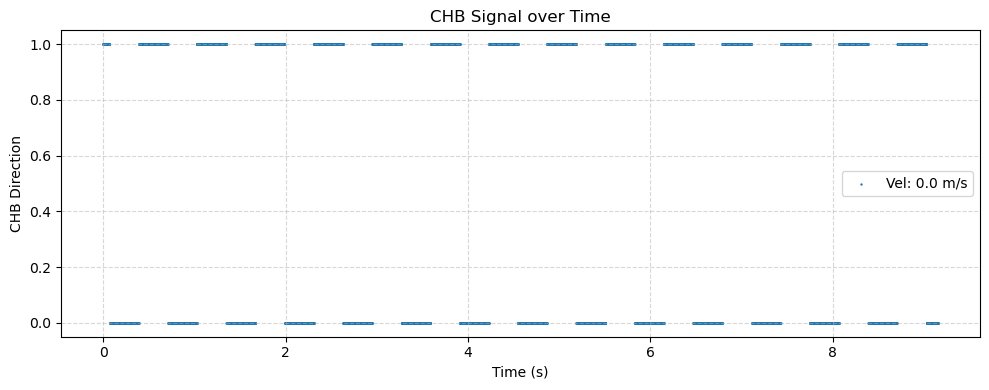

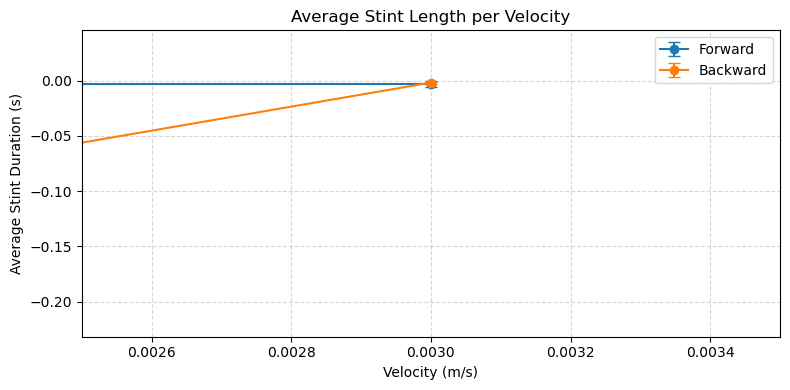

In [268]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 2. Plot CHB over time (Single Run: '0.02')
# =========================================================
plt.figure(figsize=(10, 4))
run_data = processed_runs["0.0"]
t_sec = (run_data["ts_us"] - run_data["ts_us"][0]) / 1e6

plt.scatter(
    t_sec,
    run_data["chb"],
    label=f"Vel: {run_data['velocities']} m/s",
    s= 0.5
)

plt.title("CHB Signal over Time")
plt.xlabel("Time (s)")
plt.ylabel("CHB Direction")
# plt.yticks([0, 1], ["Backward (0)", "Forward (1)"])
# plt.xlim(0, 1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# =========================================================
# 3. Plot average stint lengths per run (Connected Line)
# =========================================================
velocities = []
avg_fw_list, std_fw_list = [], []
avg_bw_list, std_bw_list = [], []

# 1. Collect data points in a loop
for run_key, run_data in processed_runs.items():
    velocities.append(float(run_key))

    # Forward stats
    fw = run_data["forward_stint_durations"]
    fw = fw[fw>0.2]
    avg_fw_list.append(np.mean(fw) if len(fw) > 0 else 0)
    std_fw_list.append(np.std(fw) if len(fw) > 0 else 0)

    # Backward stats
    bw = run_data["backward_stint_durations"]
    bw = bw[bw>0.1]
    avg_bw_list.append(np.mean(bw) if len(bw) > 0 else 0)
    std_bw_list.append(np.std(bw) if len(bw) > 0 else 0)

# 2. Sort values by velocity so the connected lines go strictly left-to-right
sort_idx = np.argsort(velocities)
velocities = np.array(velocities)[sort_idx]
avg_fw_list = np.array(avg_fw_list)[sort_idx]
std_fw_list = np.array(std_fw_list)[sort_idx]
avg_bw_list = np.array(avg_bw_list)[sort_idx]
std_bw_list = np.array(std_bw_list)[sort_idx]

# 3. Single plot call with line-and-marker format ('-o')
plt.figure(figsize=(8, 4))

plt.errorbar(
    velocities,
    avg_fw_list-0.32,
    yerr=std_fw_list,
    fmt="-o",  # '-' connects points, 'o' adds markers
    capsize=4,
    label="Forward",
)

plt.errorbar(
    velocities,
    avg_bw_list-0.32,
    yerr=std_bw_list,  # Fixed: used std_bw_list instead of std_fw
    fmt="-o",
    capsize=4,
    label="Backward",
)

plt.title("Average Stint Length per Velocity")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Average Stint Duration (s)")
plt.legend()
plt.xlim(0.0025, 0.0035)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [266]:
run_02 = processed_runs["0.02"]
fw_durations = run_02["forward_stint_durations"]

print(f"Total Forward Chunks Detected: {len(fw_durations[fw_durations>0.2])}")
print(
    f"Shortest Chunk: {np.min(fw_durations):.5f} s ({np.min(fw_durations)*1000:.2f} ms)"
)
print(f"Longest Chunk:  {np.max(fw_durations):.5f} s")
print(f"Median Chunk:   {np.median(fw_durations):.5f} s")
print(f"Mean Chunk:     {np.mean(fw_durations):.5f} s")


KeyError: '0.02'

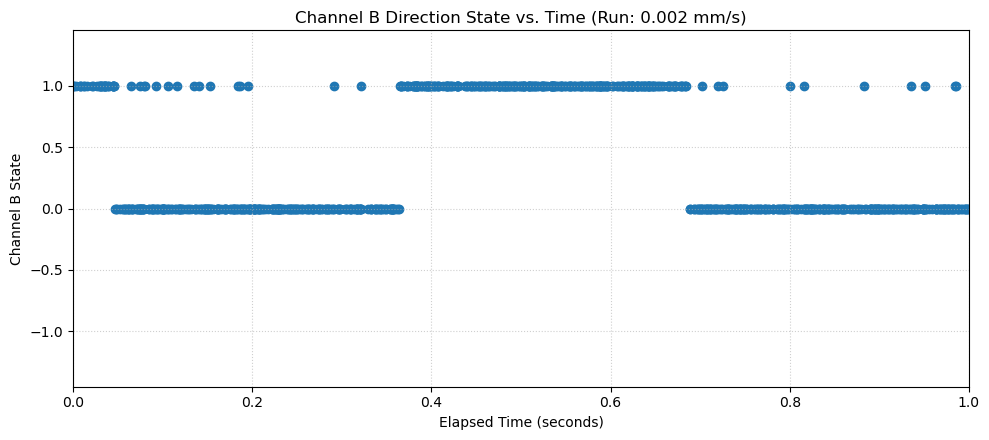

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a run key from processed_runs
run_key = list(processed_runs.keys())[0]
data = processed_runs[run_key]

# ts_us = data["ts_us"]
ts_us = np.asarray(data["ts_us"], dtype=np.float64)

chb = data["chb"]
# print(f'total chb in negative{len(chb[chb==-1])}')
t_sec = (ts_us - ts_us[0]) / 1e6

# --- Segment Duration Extraction ---
edges = np.flatnonzero(np.diff(chb) != 0) + 1
starts = np.concatenate(([0], edges))
ends = np.concatenate((edges - 1, [len(chb) - 1]))

fwd_durations = []
bwd_durations = []

for s_idx, e_idx in zip(starts, ends):
    if e_idx > s_idx:
        dur = (ts_us[e_idx] - ts_us[s_idx]) / 1e6  # Convert to seconds
        if chb[s_idx] == 1:
            fwd_durations.append(dur)
        else:
            bwd_durations.append(dur)

fwd_durations = np.array(fwd_durations)
bwd_durations = np.array(bwd_durations)


# --- Statistical Metrics Function ---
def calc_stats(durations):
    if len(durations) == 0:
        return {
            "count": 0,
            "mean": 0,
            "std": 0,
            "median": 0,
            "min": 0,
            "max": 0,
        }
    return {
        "count": len(durations),
        "mean": np.mean(durations),
        "std": np.std(durations, ddof=1) if len(durations) > 1 else 0.0,
        "median": np.median(durations),
        "min": np.min(durations),
        "max": np.max(durations),
    }


fwd_stats = calc_stats(fwd_durations)
bwd_stats = calc_stats(bwd_durations)

# Duty cycle calculation (% of time spent in Forward state)
total_time = t_sec[-1] - t_sec[0]
duty_cycle = (
    (np.sum(fwd_durations) / total_time * 100) if total_time > 0 else 0
)



# --- Plotting with Statistical Overlay ---
plt.figure(figsize=(10, 4.5))
# plt.step(t_sec, chb, where="post", color="purple", linewidth=1.5)
plt.scatter(t_sec, chb)


plt.title(f"Channel B Direction State vs. Time (Run: {run_key} mm/s)")
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Channel B State")
# plt.yticks([0, 1], ["-1 (Backward)", "1 (Forward)"])
plt.ylim(-1.45, 1.45)  # Headroom for info box
plt.xlim(0, 1)
plt.grid(True, linestyle=":", alpha=0.6)



plt.tight_layout()
plt.show()


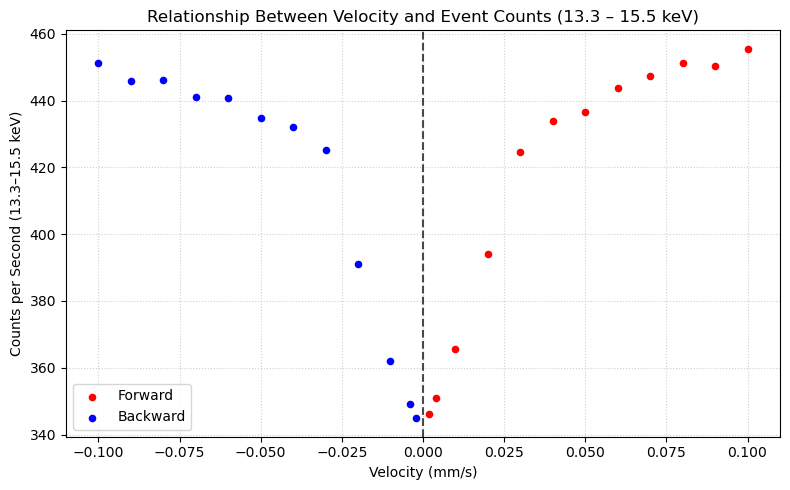

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Energy window (keV)
e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts = [], []
bwd_vels, bwd_counts = [], []

for runfile, data in processed_runs.items():
    # try:
    #     vel_raw = float(runfile.split("_")[0])
    #     vel = vel_raw / 1000.0  # Convert integer back to mm/s
    # except ValueError:
    #     print(f"Skipping {runfile}: Cannot parse numerical velocity from name.")
    #     continue
    # print(runfile)
    runfile = float(runfile)
    fwd_chunks = data["forward_energies"]
    bwd_chunks = data["backward_energies"]
    fwd_times = data["forward_times"]
    bwd_times = data["backward_times"]

    # --- Forward Direction ---
    fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6
    if fwd_dur_s > 0 and len(fwd_chunks) > 0:
        fwd_energy_all = np.concatenate(fwd_chunks)
        fwd_kev = adu_to_kev(fwd_energy_all)
        fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
        fwd_rate = fwd_count / fwd_dur_s

        if fwd_rate > 0:
            fwd_vels.append(runfile)
            fwd_counts.append(fwd_rate)

    # --- Backward Direction ---
    bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
    if bwd_dur_s > 0 and len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
        bwd_rate = bwd_count / bwd_dur_s

        if bwd_rate > 0:
            bwd_vels.append(-runfile)
            bwd_counts.append(bwd_rate)


plt.figure(figsize=(8, 5))

plt.scatter(
    fwd_vels,
    fwd_counts,
    color="red",
    label="Forward",
    marker="o",
    s=20,
    zorder=3,
)
plt.scatter(
    bwd_vels,
    bwd_counts,
    color="blue",
    label="Backward",
    marker="o",
    s=20,
    zorder=3,
)

plt.title(
    f"Relationship Between Velocity and Event Counts ({e_start} – {e_end} keV)"
)
plt.xlabel("Velocity (mm/s)")
plt.ylabel(f"Counts per Second ({e_start}–{e_end} keV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


=== Lorentzian Resonance Fit Results ===
Baseline (I0)   : 455.81 ± 0.75 cts/s
Dip Depth (A)   : 110.98 ± 0.96 cts/s
Center (v0)     : -0.0006 ± 0.0002 mm/s
FWHM (Gamma)    : 0.0428 ± 0.0009 mm/s
Degrees of Freedom: 20 (N=24, p=4)
Chi-Squared     : 74.11
Reduced Chi^2   : 3.705



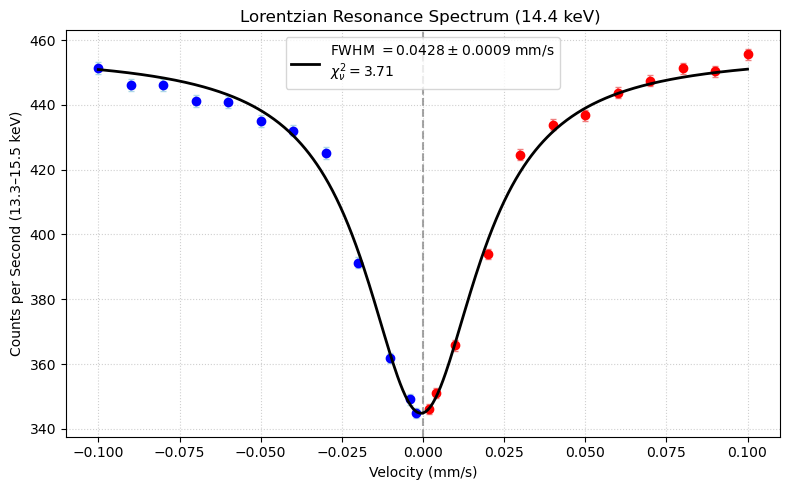

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


# 1. Define Lorentzian model (Baseline minus resonant dip)
def lorentzian(v, I0, A, v0, gamma):
    return I0 - A / (1 + ((v - v0) / gamma) ** 2)


# Energy window (keV)
e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts, fwd_errs = [], [], []
bwd_vels, bwd_counts, bwd_errs = [], [], []

for runfile, data in processed_runs.items():
    vel = float(runfile)
    fwd_chunks = data["forward_energies"]
    bwd_chunks = data["backward_energies"]
    fwd_times = data["forward_times"]
    bwd_times = data["backward_times"]

    # --- Forward Direction ---
    fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6
    if fwd_dur_s > 0 and len(fwd_chunks) > 0:
        fwd_energy_all = np.concatenate(fwd_chunks)
        fwd_kev = adu_to_kev(fwd_energy_all)
        fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
        fwd_rate = fwd_count / fwd_dur_s

        if fwd_rate > 0:
            fwd_vels.append(vel)
            fwd_counts.append(fwd_rate)
            # Poisson uncertainty in count rate: sigma = sqrt(N) / duration
            fwd_errs.append(np.sqrt(fwd_count) / fwd_dur_s)

    # --- Backward Direction ---
    bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
    if bwd_dur_s > 0 and len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
        bwd_rate = bwd_count / bwd_dur_s

        if bwd_rate > 0:
            bwd_vels.append(-vel)
            bwd_counts.append(bwd_rate)
            bwd_errs.append(np.sqrt(bwd_count) / bwd_dur_s)

# Combine datasets for weighted curve fitting
all_vels = np.array(fwd_vels + bwd_vels)
all_counts = np.array(fwd_counts + bwd_counts)
all_errs = np.array(fwd_errs + bwd_errs)

# Initial parameter guesses (p0)
I0_guess = np.max(all_counts)
v0_guess = all_vels[np.argmin(all_counts)]
A_guess = I0_guess - np.min(all_counts)
gamma_guess = 0.05  # HWHM initial guess (mm/s)

p0 = [I0_guess, A_guess, v0_guess, gamma_guess]

# Weighted non-linear least squares fit
popt, pcov = curve_fit(
    lorentzian,
    all_vels,
    all_counts,
    p0=p0,
    sigma=all_errs,
    absolute_sigma=True,
)
perr = np.sqrt(np.diag(pcov))

# --- Reduced Chi-Squared Calculation ---
residuals = all_counts - lorentzian(all_vels, *popt)
chi2 = np.sum((residuals / all_errs) ** 2)
dof = len(all_counts) - len(popt)  # Degrees of freedom (N - p)
red_chi2 = chi2 / dof

I0_fit, A_fit, v0_fit, gamma_fit = popt
fwhm_fit = 2 * abs(gamma_fit)
fwhm_err = 2 * perr[3]

# Print Summary
print("=== Lorentzian Resonance Fit Results ===")
print(f"Baseline (I0)   : {I0_fit:.2f} ± {perr[0]:.2f} cts/s")
print(f"Dip Depth (A)   : {A_fit:.2f} ± {perr[1]:.2f} cts/s")
print(f"Center (v0)     : {v0_fit:.4f} ± {perr[2]:.4f} mm/s")
print(f"FWHM (Gamma)    : {fwhm_fit:.4f} ± {fwhm_err:.4f} mm/s")
print(f"Degrees of Freedom: {dof} (N={len(all_counts)}, p={len(popt)})")
print(f"Chi-Squared     : {chi2:.2f}")
print(f"Reduced Chi^2   : {red_chi2:.3f}\n")

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Scatter data with Poisson error bars
plt.errorbar(
    fwd_vels,
    fwd_counts,
    yerr=fwd_errs,
    fmt="o",
    color="red",
    ecolor="lightcoral",
    capsize=2,
    # label="Forward Data",
    zorder=3,
)
plt.errorbar(
    bwd_vels,
    bwd_counts,
    yerr=bwd_errs,
    fmt="o",
    color="blue",
    ecolor="lightblue",
    capsize=2,
    # label="Backward Data",
    zorder=3,
)

# Plot dense fit curve
v_dense = np.linspace(np.min(all_vels), np.max(all_vels), 500)
fit_curve = lorentzian(v_dense, *popt)

fit_label = (
    # f"Lorentzian Fit\n"
    # f"$v_0 = {v0_fit:.4f} \\pm {perr[2]:.4f}$ mm/s\n"
    f"FWHM $= {fwhm_fit:.4f} \\pm {fwhm_err:.4f}$ mm/s\n"
    f"$\\chi_\\nu^2 = {red_chi2:.2f}$"
)

plt.plot(
    v_dense,
    fit_curve,
    color="black",
    linestyle="-",
    linewidth=2,
    label=fit_label,
    zorder=4,
)
average_kev = (e_start + e_end)/2
title = f"Lorentzian Resonance Spectrum ({average_kev:.1f} keV) "
plt.title(title)
plt.xlabel("Velocity (mm/s)")
plt.ylabel(f"Counts per Second ({e_start}–{e_end} keV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.axvline(0, linestyle="--", color="gray", alpha=0.7)
plt.legend(loc="upper center")
plt.tight_layout()
save = False
if save:
        clean_label = title.lower().replace(" ", "_")
        base_path = Path(f"{clean_label}kev.png")
        save_path = base_path
        counter = 1

        while save_path.exists():
            save_path = base_path.with_name(
                f"{base_path.stem}_{counter}{base_path.suffix}"
            )
            counter += 1

        plt.savefig(save_path, transparent=True, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
plt.show()


=== Lorentzian Resonance Fit Results ===
Baseline (I0)   : 437.15 ± 0.97 cts/s
Dip Depth (A)   : 103.54 ± 1.40 cts/s
Center (v0)     : 0.0019 ± 0.0004 mm/s
FWHM (Gamma)    : 0.0354 ± 0.0012 mm/s
Degrees of Freedom: 20 (N=24, p=4)
Chi-Squared     : 54.62
Reduced Chi^2   : 2.731



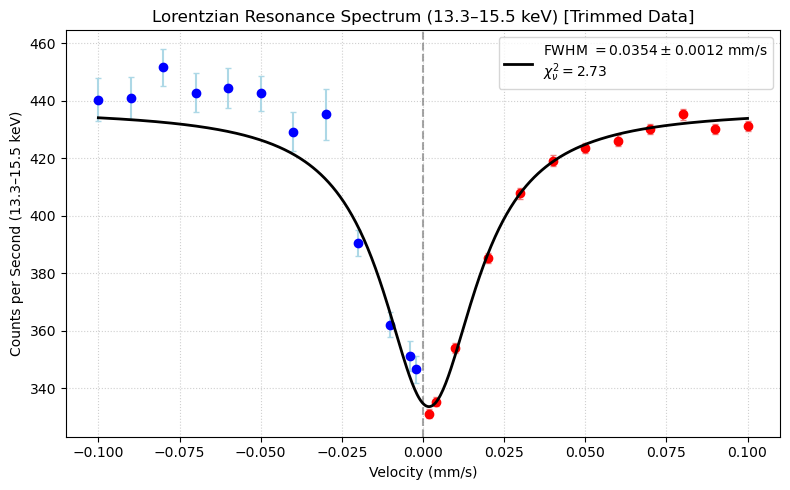

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit


# 1. Define Lorentzian model (Baseline minus resonant dip)
def lorentzian(v, I0, A, v0, gamma):
    return I0 - A / (1 + ((v - v0) / gamma) ** 2)


# Energy window (keV)
e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts, fwd_errs = [], [], []
bwd_vels, bwd_counts, bwd_errs = [], [], []

for runfile, data in processed_runs.items():
    vel = float(runfile)
    fwd_chunks = data["forward_energies_trimmed"]
    bwd_chunks = data["backward_energies_trimmed"]
    fwd_times = data["forward_times_trimmed"]
    bwd_times = data["backward_times_trimmed"]

    # --- Forward Direction ---
    fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6
    if fwd_dur_s > 0 and len(fwd_chunks) > 0:
        fwd_energy_all = np.concatenate(fwd_chunks)
        fwd_kev = adu_to_kev(fwd_energy_all)
        fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
        fwd_rate = fwd_count / fwd_dur_s

        if fwd_rate > 0:
            fwd_vels.append(vel)
            fwd_counts.append(fwd_rate)
            # Poisson uncertainty in count rate: sigma = sqrt(N) / duration
            fwd_errs.append(np.sqrt(fwd_count) / fwd_dur_s)

    # --- Backward Direction ---
    bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
    if bwd_dur_s > 0 and len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
        bwd_rate = bwd_count / bwd_dur_s

        if bwd_rate > 0:
            bwd_vels.append(-vel)
            bwd_counts.append(bwd_rate)
            bwd_errs.append(np.sqrt(bwd_count) / bwd_dur_s)

# Combine datasets for weighted curve fitting
all_vels = np.array(fwd_vels + bwd_vels)
all_counts = np.array(fwd_counts + bwd_counts)
all_errs = np.array(fwd_errs + bwd_errs)

# Initial parameter guesses (p0)
I0_guess = np.max(all_counts)
v0_guess = all_vels[np.argmin(all_counts)]
A_guess = I0_guess - np.min(all_counts)
gamma_guess = 0.05  # HWHM initial guess (mm/s)

p0 = [I0_guess, A_guess, v0_guess, gamma_guess]

# Weighted non-linear least squares fit
popt, pcov = curve_fit(
    lorentzian,
    all_vels,
    all_counts,
    p0=p0,
    sigma=all_errs,
    absolute_sigma=True,
)
perr = np.sqrt(np.diag(pcov))

# --- Reduced Chi-Squared Calculation ---
residuals = all_counts - lorentzian(all_vels, *popt)
chi2 = np.sum((residuals / all_errs) ** 2)
dof = len(all_counts) - len(popt)  # Degrees of freedom (N - p)
red_chi2 = chi2 / dof

I0_fit, A_fit, v0_fit, gamma_fit = popt
fwhm_fit = 2 * abs(gamma_fit)
fwhm_err = 2 * perr[3]

# Print Summary
print("=== Lorentzian Resonance Fit Results ===")
print(f"Baseline (I0)   : {I0_fit:.2f} ± {perr[0]:.2f} cts/s")
print(f"Dip Depth (A)   : {A_fit:.2f} ± {perr[1]:.2f} cts/s")
print(f"Center (v0)     : {v0_fit:.4f} ± {perr[2]:.4f} mm/s")
print(f"FWHM (Gamma)    : {fwhm_fit:.4f} ± {fwhm_err:.4f} mm/s")
print(f"Degrees of Freedom: {dof} (N={len(all_counts)}, p={len(popt)})")
print(f"Chi-Squared     : {chi2:.2f}")
print(f"Reduced Chi^2   : {red_chi2:.3f}\n")

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Scatter data with Poisson error bars
plt.errorbar(
    fwd_vels,
    fwd_counts,
    yerr=fwd_errs,
    fmt="o",
    color="red",
    ecolor="lightcoral",
    capsize=2,
    # label="Forward Data",
    zorder=3,
)
plt.errorbar(
    bwd_vels,
    bwd_counts,
    yerr=bwd_errs,
    fmt="o",
    color="blue",
    ecolor="lightblue",
    capsize=2,
    # label="Backward Data",
    zorder=3,
)

# Plot dense fit curve
v_dense = np.linspace(np.min(all_vels), np.max(all_vels), 500)
fit_curve = lorentzian(v_dense, *popt)

fit_label = (
    # f"Lorentzian Fit\n"
    # f"$v_0 = {v0_fit:.4f} \\pm {perr[2]:.4f}$ mm/s\n"
    f"FWHM $= {fwhm_fit:.4f} \\pm {fwhm_err:.4f}$ mm/s\n"
    f"$\\chi_\\nu^2 = {red_chi2:.2f}$"
)

plt.plot(
    v_dense,
    fit_curve,
    color="black",
    linestyle="-",
    linewidth=2,
    label=fit_label,
    zorder=4,
)

plt.title(
    f"Lorentzian Resonance Spectrum ({e_start}–{e_end} keV) [Trimmed Data]"
)
plt.xlabel("Velocity (mm/s)")
plt.ylabel(f"Counts per Second ({e_start}–{e_end} keV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.axvline(0, linestyle="--", color="gray", alpha=0.7)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
h_all = {}
adu_all = {}

for label, run in processed_runs.items():
    energy = run["energy"]

    # Define integer ADU bins spanning the min-to-max range
    min_adu = int(np.floor(np.min(energy)))
    max_adu = int(np.ceil(np.max(energy)))
    bins = np.arange(min_adu, max_adu + 2)

    # Compute histogram
    h, b = np.histogram(energy, bins=bins)
    bin_centers = 0.5 * (b[:-1] + b[1:])  # Proper bin centers instead of right edges

    h_all[label] = (h)
    adu_all[label] = (bin_centers)


22551


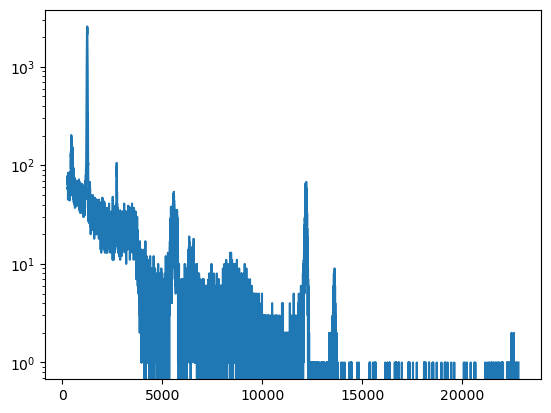

In [ ]:
plt.plot(adu_all['0.02'],h_all['0.02'], label ='0.02')

# plt.plot(adu_all[1],h_all[1], alpha =0.3, color = 'red', label = 'With Absorber')

plt.yscale('log')
# plt.xscale('log')
# plt.xlim(kev_to_adu(13),kev_to_adu(16))

##RATE WITH AND WITHOUT ABSORBR
print(len(adu_all['0.02']))